# Stage 1 climate-cache QC (`.npz` + `.pkl`)

## Goal

Run climate-only quality control directly on the downloaded Stage 1 cache. This replaces the earlier NetCDF-centric workflow: it checks the converged pressure-temperature profile and exact PICASO climate diagnostics in each `.npz`, verifies the matching PICASO case `.pkl`, and deliberately skips reflected-spectrum and final NetCDF schema checks.

Outputs are written to `CACHE_DIR/qc/` as CSV and JSON so the full pass is auditable.

## Setup

The notebook prefers the production cache downloaded to `outputs/aurora_subneptune_v1_dhuang/climate_cache`. If that folder is absent it falls back to the small `sample_outputs` folder for a smoke test.

Set `AURORA_CACHE_DIR`, `AURORA_CACHE_LIMIT`, or the variables below before running if needed. Pickles are trusted model outputs from this project; do not unpickle files from unknown sources.

In [1]:
from __future__ import annotations

import json
import os
import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repository whether Jupyter starts at repo root or in notebooks/.
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    grid_candidate = candidate / "roadrunner_egp" / "aurora_subneptune_grid"
    if (grid_candidate / "src" / "aurora_grid").is_dir():
        REPO_ROOT = candidate
        GRID_ROOT = grid_candidate
        break
else:
    raise FileNotFoundError("Could not locate roadrunner_egp/aurora_subneptune_grid")

SRC_ROOT = GRID_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# PICASO needs these paths when a case pickle is actually loaded.
local_refdata = REPO_ROOT / "picaso4_reference"
if local_refdata.is_dir():
    os.environ.setdefault("picaso_refdata", str(local_refdata))
    os.environ.setdefault("PYSYN_CDBS", str(local_refdata / "stellar_grids"))

from aurora_grid.qc.climate_cache import (
    climate_group_index,
    discover_cache_files,
    validate_cache_paths,
    write_cache_reports,
)

production_cache = GRID_ROOT / "outputs" / "aurora_subneptune_v1_dhuang" / "climate_cache"
default_cache = production_cache if production_cache.exists() else GRID_ROOT / "sample_outputs"
CACHE_DIR = Path(os.environ.get("AURORA_CACHE_DIR", default_cache)).expanduser().resolve()
LIMIT_TEXT = os.environ.get("AURORA_CACHE_LIMIT", "").strip()
LIMIT = int(LIMIT_TEXT) if LIMIT_TEXT else None
UNPICKLE_SAMPLE = 12       # pair existence is always checked; actually load only this many case objects
PROFILE_COUNT = 12       # number of profiles overplotted in the diagnostic figure
REPORT_DIR = CACHE_DIR / "qc"

print(f"CACHE_DIR={CACHE_DIR}")
print(f"LIMIT={LIMIT or 'all'}")

CACHE_DIR=/Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache
LIMIT=all


## Checks

Each cache receives the existing Aurora P–T and exact-climate checks where the diagnostic arrays are present:

- NPZ readability, required keys, JSON metadata, and filename/metadata index agreement
- matching case-pickle existence, with a small evenly spaced unpickle sample
- finite, positive, shape-matched P–T arrays and monotonic pressure
- convergence flag, extreme layer jumps, and runaway `dT/dlogP`
- PICASO adiabat ratio and upper-atmosphere flux-balance thresholds
- brightness-temperature depth check when the full array is present (older compact metadata may contain only a summary)

In [2]:
inventory = discover_cache_files(CACHE_DIR, limit=LIMIT)
if not inventory.npz_paths:
    raise FileNotFoundError(f"No climate_*.npz files found in {CACHE_DIR}")

sample_count = min(UNPICKLE_SAMPLE, len(inventory.npz_paths))
positions = {
    round(i * (len(inventory.npz_paths) - 1) / max(1, sample_count - 1))
    for i in range(sample_count)
}
unpickle_indices = {
    index
    for position in positions
    if (index := climate_group_index(inventory.npz_paths[position])) is not None
}

print(f"NPZ files selected: {len(inventory.npz_paths):,}")
print(f"Orphan PKL files: {len(inventory.orphan_pkl_paths):,}")
print(f"PKL objects sampled for actual unpickling: {sorted(unpickle_indices)}")

NPZ files selected: 27,627
Orphan PKL files: 0
PKL objects sampled for actual unpickling: [0, 2711, 5623, 8334, 11246, 13957, 16869, 19580, 22492, 25403, 28115, 31719]


## Results

In [3]:
summaries, flag_records = validate_cache_paths(
    inventory.npz_paths,
    unpickle_indices=unpickle_indices,
)
summary_df = pd.DataFrame(summaries)
flags_df = pd.DataFrame(flag_records)
summary_csv, flags_csv, summary_json = write_cache_reports(
    summaries,
    flag_records,
    REPORT_DIR,
)

status_counts = summary_df["status"].value_counts(dropna=False)
display(status_counts.rename("count").to_frame())
print(f"Summary: {summary_csv}")
print(f"Flags:   {flags_csv}")
print(f"JSON:    {summary_json}")

,count
status,
pass,24578
warning,1816
rerun_recommended,1233


Summary: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache/qc/climate_cache_qc_summary.csv
Flags:   /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache/qc/climate_cache_qc_flags.csv
JSON:    /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache/qc/climate_cache_qc_summary.json


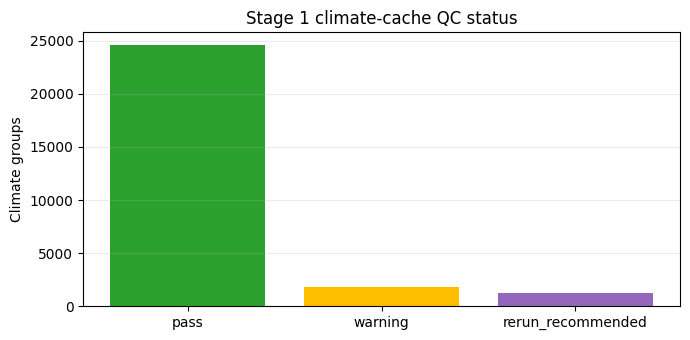

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = [name for name in ("pass", "warning", "fail", "rerun_recommended") if name in status_counts]
colors = {"pass": "#2ca02c", "warning": "#ffbf00", "fail": "#d62728", "rerun_recommended": "#9467bd"}
ax.bar(order, [status_counts[name] for name in order], color=[colors[name] for name in order])
ax.set(title="Stage 1 climate-cache QC status", ylabel="Climate groups")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
columns = [
    "climate_group_index", "status", "climate_converged", "pkl_exists",
    "temperature_min_k", "temperature_max_k", "max_adiabat_ratio",
    "max_abs_fnet_irfnet", "fail_reasons", "warning_reasons",
]
flagged_df = summary_df.loc[summary_df["status"] != "pass", columns]
print(f"Flagged climate groups: {len(flagged_df):,}")
display(flagged_df.head(50))

Flagged climate groups: 3,049


,climate_group_index,status,climate_converged,pkl_exists,temperature_min_k,temperature_max_k,max_adiabat_ratio,max_abs_fnet_irfnet,fail_reasons,warning_reasons
21,21,warning,1,True,241.555091,2446.788968,1.026604,0.703829,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
41,41,warning,1,True,241.634966,2443.279291,1.026605,0.696392,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
221,221,warning,1,True,242.518176,2437.816120,1.026605,0.765881,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
241,241,warning,1,True,242.596998,2434.321798,1.026606,0.758057,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
420,420,warning,1,True,207.076587,2194.884828,1.016054,0.863328,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
421,421,warning,1,True,243.407623,2432.197597,1.026606,0.859907,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
440,440,warning,1,True,207.125959,2191.399902,1.016054,0.855505,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
441,441,warning,1,True,243.477704,2427.399086,1.026607,0.851691,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
620,620,warning,1,True,211.986925,2397.390471,1.026263,3.723510,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...
621,621,warning,1,True,249.749662,2621.774779,1.030774,10.117759,,Fnet/IR-Fnet > 1e-03 at 32 upper-atmosphere la...


### Profile diagnostics

The plot samples the full index range so a large run remains readable. It shows the cached P–T curves, exact `dT/dP` to adiabat ratio when available, and normalized net-flux residual. Horizontal pressure is in bar; the pressure axis is inverted in the atmospheric convention.

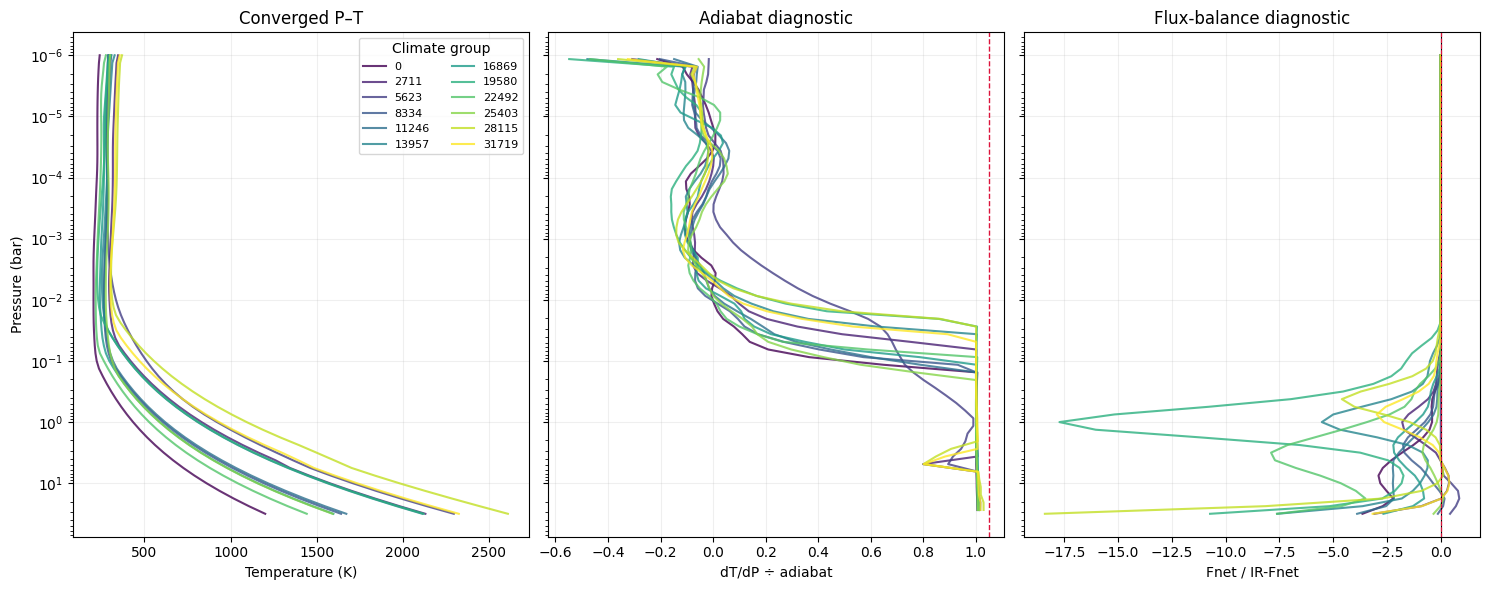

In [6]:
profile_count = min(PROFILE_COUNT, len(inventory.npz_paths))
profile_positions = sorted({
    round(i * (len(inventory.npz_paths) - 1) / max(1, profile_count - 1))
    for i in range(profile_count)
})
profile_paths = [inventory.npz_paths[position] for position in profile_positions]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(profile_paths)))
for color, path in zip(colors, profile_paths):
    with np.load(path, allow_pickle=False) as archive:
        pressure = np.asarray(archive["pressure"], dtype=float)
        temperature = np.asarray(archive["temperature"], dtype=float)
        metadata = json.loads(str(archive["metadata_json"]))
    diagnostics = metadata.get("diagnostics", {})
    label = str(metadata.get("climate_group_index", climate_group_index(path)))
    axes[0].plot(temperature, pressure, color=color, alpha=0.8, label=label)

    dtdp = diagnostics.get("qc_dtdp")
    adiabat = diagnostics.get("qc_adiabat")
    diag_pressure = diagnostics.get("qc_adiabat_pressure")
    if isinstance(dtdp, list) and isinstance(adiabat, list) and len(dtdp) == len(adiabat):
        ratio = np.asarray(dtdp, dtype=float) / np.asarray(adiabat, dtype=float)
        p_ratio = np.asarray(diag_pressure if isinstance(diag_pressure, list) else pressure[: len(ratio)], dtype=float)
        axes[1].plot(ratio, p_ratio, color=color, alpha=0.8)

    fnet = diagnostics.get("fnet_irfnet")
    if isinstance(fnet, list):
        fnet = np.asarray(fnet, dtype=float)
        p_fnet = pressure if len(fnet) == len(pressure) else pressure[: len(fnet)]
        axes[2].plot(fnet, p_fnet, color=color, alpha=0.8)

axes[0].set(xlabel="Temperature (K)", ylabel="Pressure (bar)", title="Converged P–T")
axes[1].set(xlabel="dT/dP ÷ adiabat", title="Adiabat diagnostic")
axes[1].axvline(1.05, color="crimson", ls="--", lw=1, label="QC threshold")
axes[2].set(xlabel="Fnet / IR-Fnet", title="Flux-balance diagnostic")
axes[2].axvline(0, color="black", lw=0.8)
axes[2].axvline(1e-3, color="crimson", ls="--", lw=0.8)
axes[2].axvline(-1e-3, color="crimson", ls="--", lw=0.8)
for ax in axes:
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.grid(alpha=0.2)
axes[0].legend(title="Climate group", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Inspect chemistry from one case pickle

The `.pkl` stores the PICASO inputs object and its atmospheric chemistry profile. This cell loads one of the already sampled trusted pickles and plots common major species when present.

Loaded climate_00_case.pkl; object type=inputs
Available major species: ['H2', 'He', 'H2O', 'CH4', 'CO', 'NH3', 'CO2']


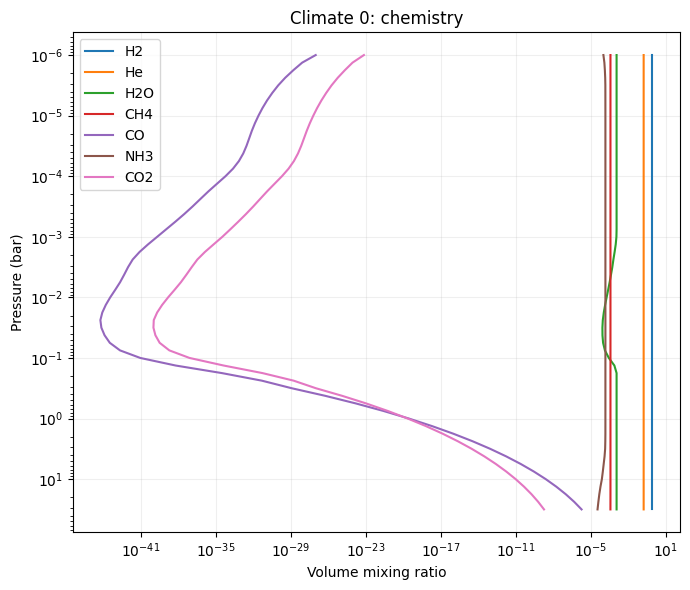

In [7]:
selected_index = min(unpickle_indices) if unpickle_indices else climate_group_index(inventory.npz_paths[0])
selected_npz = next(path for path in inventory.npz_paths if climate_group_index(path) == selected_index)
selected_pkl = selected_npz.with_name(f"{selected_npz.stem}_case.pkl")

if not selected_pkl.exists():
    print(f"No paired pickle for climate group {selected_index}: {selected_pkl}")
else:
    with selected_pkl.open("rb") as handle:
        case = pickle.load(handle)
    profile = case.inputs["atmosphere"]["profile"]
    pressure_profile = np.asarray(profile["pressure"], dtype=float)
    major_species = ["H2", "He", "H2O", "CH4", "CO", "NH3", "CO2"]
    available = [name for name in major_species if name in profile]
    print(f"Loaded {selected_pkl.name}; object type={type(case).__name__}")
    print(f"Available major species: {available}")
    fig, ax = plt.subplots(figsize=(7, 6))
    for species in available:
        abundance = np.asarray(profile[species], dtype=float)
        if np.nanmax(abundance) > 1e-50:
            ax.plot(abundance, pressure_profile, label=species)
    ax.set(xscale="log", yscale="log", xlabel="Volume mixing ratio", ylabel="Pressure (bar)", title=f"Climate {selected_index}: chemistry")
    ax.invert_yaxis()
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Takeaways

- Use `climate_cache_qc_summary.csv` to filter climate groups by `status` and `rerun_recommended`.
- Missing `.pkl` pairs and non-converged climates are treated as rerun candidates because Stage 2 cannot safely reuse them.
- Warnings retain usable caches but should be reviewed in the profile diagnostics.
- Re-run the notebook without `AURORA_CACHE_LIMIT` for the full downloaded corpus; use the CLI below for a non-interactive batch pass:

```bash
.venv-picaso4/bin/python roadrunner_egp/aurora_subneptune_grid/scripts/qc_climate_cache.py \
  --cache-dir roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache \
  --unpickle-sample 12
```